# Step 2 (3D) — Exploratory Data Analysis (EDA)
**Dataset**: BraTS-PEDs-v1 — pipeline 3D
**Goal**: Caricare i volumi NIfTI grezzi da `data/raw/`, visualizzare le 4 modalita' MRI e la maschera di segmentazione su una slice centrale, ispezionare le distribuzioni di intensita' e la frequenza delle label.

**Differenza critica rispetto al vecchio progetto 2D (`master/notebooks/01_EDA.ipynb`)**: qui si mantengono le **5 classi native** della convenzione pediatrica BraTS-PEDs — NESSUNA remap `label 4 -> 3`. Il vecchio progetto applicava `np.where(seg_raw == 4, 3, seg_raw)` copiando una convenzione BraTS-adulti non applicabile qui; verificato empiricamente (`scripts/verify_label_mapping.py`) che 27/257 soggetti (10.5%) hanno le label 3 e 4 co-presenti come regioni cliniche distinte — quella remap fonderebbe illegittimamente Cystic Component (3) ed Edema (4).

Convenzione a 5 classi (`src/constants.py`): `0=BG, 1=ET, 2=NET, 3=CC, 4=ED`.

In [1]:
import os
import sys
import glob
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

sys.path.insert(0, os.path.abspath('..'))
from src.constants import NUM_CLASSES, CLASS_NAMES

print('nibabel version:', nib.__version__)
print('numpy  version:', np.__version__)
print(f'NUM_CLASSES = {NUM_CLASSES}')
print(f'CLASS_NAMES = {CLASS_NAMES}')

nibabel version: 5.4.2
numpy  version: 2.5.1
NUM_CLASSES = 5
CLASS_NAMES = ('background', 'ET', 'NET', 'CC', 'ED')


## 1. Dataset Paths

A differenza del 2D (che leggeva da una cartella copiata dentro il progetto), qui i volumi grezzi vivono in `data/raw/BraTS-PEDs-v1/Training/` (fase LOCALE della Dicotomia Locale/Cloud — nessun preprocessing numerico applicato ancora).

In [2]:
TRAIN_DIR = os.path.join('..', 'data', 'raw', 'BraTS-PEDs-v1', 'Training')

subjects = sorted(os.listdir(TRAIN_DIR))
print(f'Total training subjects: {len(subjects)}')
print('First 5:', subjects[:5])

Total training subjects: 257
First 5: ['BraTS-PED-00001-000', 'BraTS-PED-00002-000', 'BraTS-PED-00003-000', 'BraTS-PED-00004-000', 'BraTS-PED-00005-000']


## 2. Load One Subject

In [3]:
SUBJECT = subjects[0]  # BraTS-PED-00001-000
subj_dir = os.path.join(TRAIN_DIR, SUBJECT)

MODALITIES = ['t1c', 't1n', 't2f', 't2w']

volumes = {}
for mod in MODALITIES:
    path = os.path.join(subj_dir, f'{SUBJECT}-{mod}.nii.gz')
    img = nib.load(path)
    volumes[mod] = img.get_fdata().astype(np.float32)

seg_path = os.path.join(subj_dir, f'{SUBJECT}-seg.nii.gz')
seg = nib.load(seg_path).get_fdata().astype(np.int16)

# NESSUNA remap: le 5 classi native {0,1,2,3,4} sono mantenute cosi' come sono.
print(f'Subject: {SUBJECT}')
print(f'Volume shape: {volumes["t1c"].shape}   (H x W x D)')
print(f'Unique labels (5 classi native, nessuna remap): {np.unique(seg)}')

Subject: BraTS-PED-00001-000
Volume shape: (240, 240, 155)   (H x W x D)
Unique labels (5 classi native, nessuna remap): [0 1 2 3 4]


## 3. Affine & Voxel Spacing

In [4]:
img_nib = nib.load(os.path.join(subj_dir, f'{SUBJECT}-t1c.nii.gz'))
header = img_nib.header
voxel_size = header.get_zooms()
print(f'Voxel size (mm): {voxel_size}')
print(f'Affine matrix:\n{img_nib.affine}')

Voxel size (mm): (np.float32(1.0), np.float32(1.0), np.float32(1.0))
Affine matrix:
[[ -1.   0.   0.  -0.]
 [  0.  -1.   0. 239.]
 [  0.   0.   1.   0.]
 [  0.   0.   0.   1.]]


## 4. Visualise a Central Axial Slice — All 4 Modalities + Segmentation Mask

Nel 3D il volume non viene piu' spezzettato in slice per il training (quello lo fa `RandCropByPosNegLabeld` on-the-fly su Colab, non l'EDA). Qui, per ispezione visiva, si preleva una singola slice lungo l'asse Z — non necessariamente quella con l'area tumorale massima come nel vecchio EDA 2D (che serviva a selezionare la slice piu' informativa per un modello slice-based): si usa la slice **centrale** del volume come vista rappresentativa generica, ma si evidenzia comunque quella con la massima area tumorale per confronto.

Slice centrale (asse Z): 77 / 155
Slice con area tumorale massima: 91


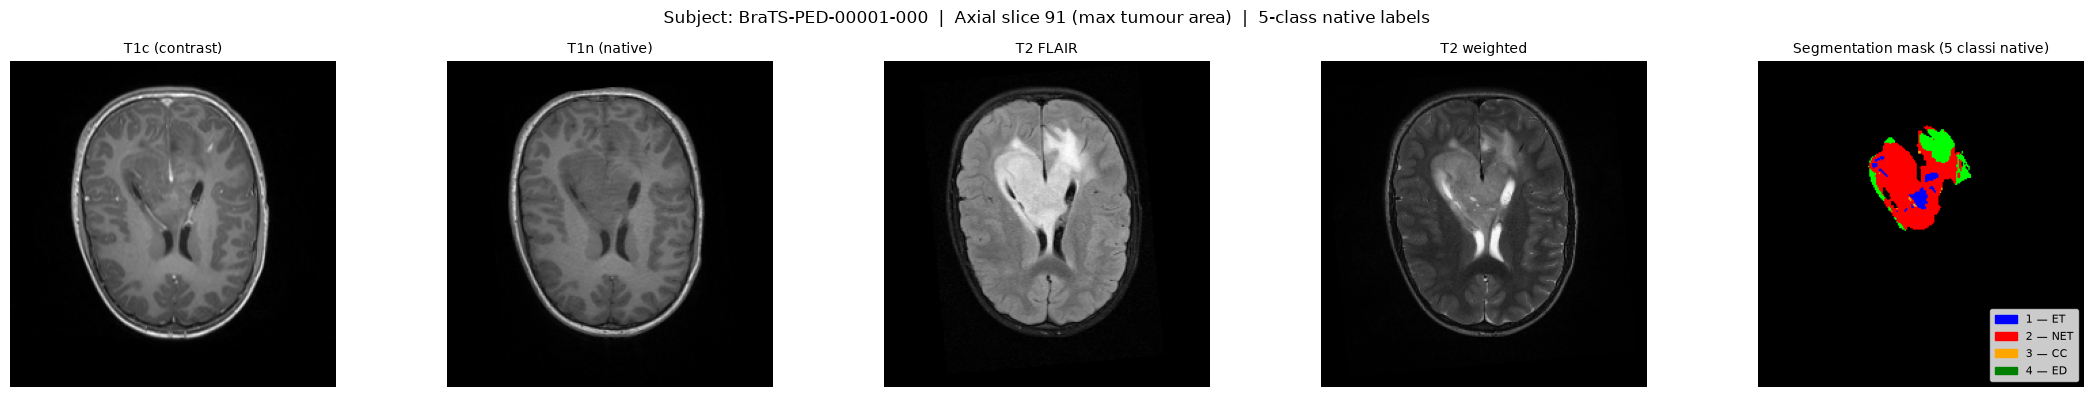

In [5]:
# Slice centrale sull'asse Z (rappresentativa del volume, non selezionata sul tumore)
central_slice_idx = volumes['t1c'].shape[2] // 2

# Per confronto: la slice con la massima area tumorale (come nel vecchio EDA 2D)
tumor_mask = (seg > 0)
max_tumor_slice_idx = int(np.argmax(tumor_mask.sum(axis=(0, 1))))

print(f'Slice centrale (asse Z): {central_slice_idx} / {volumes["t1c"].shape[2]}')
print(f'Slice con area tumorale massima: {max_tumor_slice_idx}')

slice_idx = max_tumor_slice_idx  # usiamo quella piu' informativa per la visualizzazione

LABEL_COLORS = {
    0: [0, 0, 0],        # Background — nero
    1: [0, 0, 255],      # ET (Enhancing Tumor) — blu
    2: [255, 0, 0],      # NET (Non-Enhancing Tumor) — rosso
    3: [255, 165, 0],    # CC (Cystic Component) — arancione
    4: [0, 255, 0],      # ED (Peritumoral Edema) — verde
}

def seg_to_rgb(seg_slice):
    h, w = seg_slice.shape
    rgb = np.zeros((h, w, 3), dtype=np.uint8)
    for label, color in LABEL_COLORS.items():
        rgb[seg_slice == label] = color
    return rgb

fig, axes = plt.subplots(1, 5, figsize=(22, 4))
mod_titles = ['T1c (contrast)', 'T1n (native)', 'T2 FLAIR', 'T2 weighted']

for i, (mod, title) in enumerate(zip(MODALITIES, mod_titles)):
    sl = volumes[mod][:, :, slice_idx]
    axes[i].imshow(sl.T, cmap='gray', origin='lower')
    axes[i].set_title(title, fontsize=10)
    axes[i].axis('off')

rgb = seg_to_rgb(seg[:, :, slice_idx].T)
axes[4].imshow(rgb, origin='lower')
axes[4].set_title('Segmentation mask (5 classi native)', fontsize=10)
axes[4].axis('off')

patches = [
    mpatches.Patch(color='blue',   label='1 — ET'),
    mpatches.Patch(color='red',    label='2 — NET'),
    mpatches.Patch(color='orange', label='3 — CC'),
    mpatches.Patch(color='green',  label='4 — ED'),
]
axes[4].legend(handles=patches, loc='lower right', fontsize=8)
plt.suptitle(f'Subject: {SUBJECT}  |  Axial slice {slice_idx} (max tumour area)  |  5-class native labels', fontsize=12)
plt.tight_layout()
plt.savefig('eda_3d_slice_overview.png', dpi=120, bbox_inches='tight')
plt.show()

## 5. Overlay Segmentation on T1c

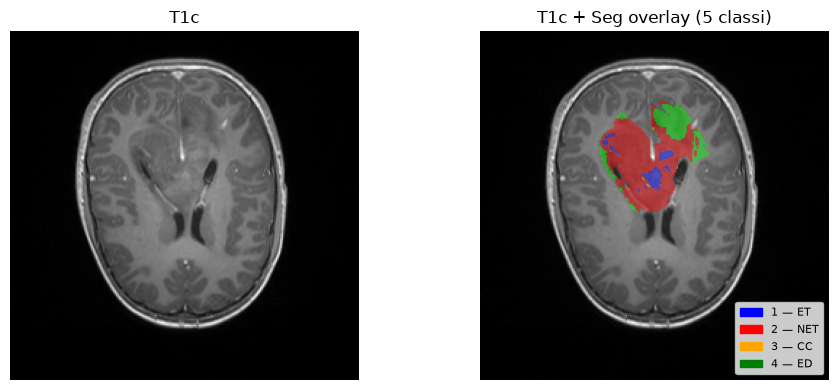

In [6]:
t1c_sl = volumes['t1c'][:, :, slice_idx].T
seg_sl = seg[:, :, slice_idx].T

t1c_norm = (t1c_sl - t1c_sl.min()) / (t1c_sl.max() - t1c_sl.min() + 1e-8)
rgb_base = np.stack([t1c_norm] * 3, axis=-1)

overlay = rgb_base.copy()
alpha = 0.45
color_map = {1: [0, 0, 1], 2: [1, 0, 0], 3: [1, 0.65, 0], 4: [0, 1, 0]}  # 5 classi native
for label, color in color_map.items():
    mask = seg_sl == label
    for c in range(3):
        overlay[:, :, c] = np.where(mask, (1 - alpha) * rgb_base[:, :, c] + alpha * color[c], overlay[:, :, c])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.imshow(t1c_norm, cmap='gray', origin='lower'); ax1.set_title('T1c'); ax1.axis('off')
ax2.imshow(overlay, origin='lower'); ax2.set_title('T1c + Seg overlay (5 classi)'); ax2.axis('off')
ax2.legend(handles=patches, loc='lower right', fontsize=8)
plt.tight_layout()
plt.savefig('eda_3d_overlay.png', dpi=120, bbox_inches='tight')
plt.show()

## 6. Intensity Distributions per Modality

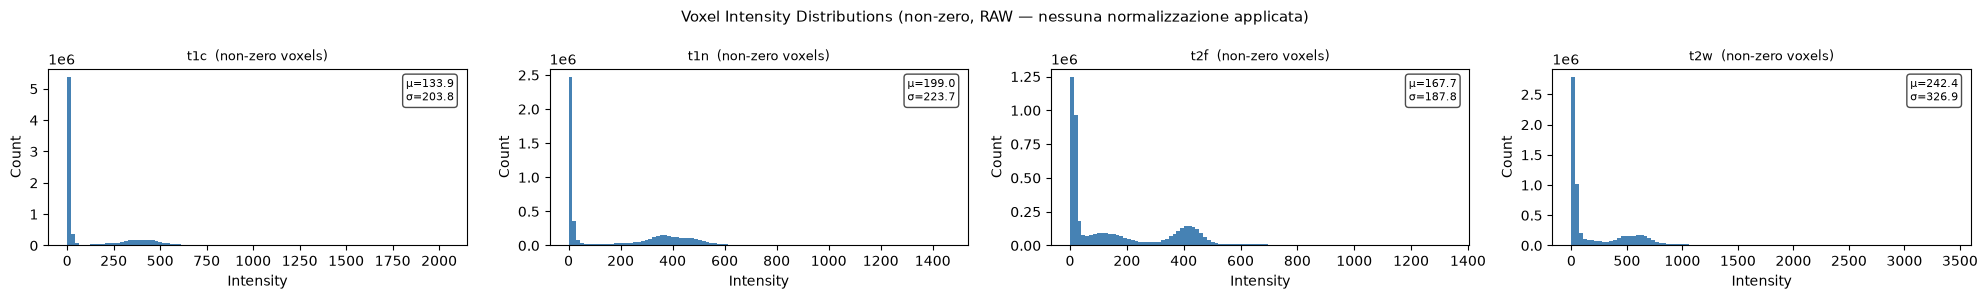

In [7]:
fig, axes = plt.subplots(1, 4, figsize=(20, 3))
for ax, mod in zip(axes, MODALITIES):
    v = volumes[mod]
    non_zero = v[v > 0].flatten()
    ax.hist(non_zero, bins=100, color='steelblue', edgecolor='none')
    ax.set_title(f'{mod}  (non-zero voxels)', fontsize=9)
    ax.set_xlabel('Intensity'); ax.set_ylabel('Count')
    ax.text(0.97, 0.95, f'\u03bc={non_zero.mean():.1f}\n\u03c3={non_zero.std():.1f}',
            ha='right', va='top', transform=ax.transAxes, fontsize=8,
            bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.7))
plt.suptitle('Voxel Intensity Distributions (non-zero, RAW — nessuna normalizzazione applicata)', fontsize=11)
plt.tight_layout()
plt.savefig('eda_3d_intensity_distributions.png', dpi=120, bbox_inches='tight')
plt.show()

## 7. Label Frequency Analysis (tutti i 257 soggetti training, 5 classi native)

In [8]:
from tqdm import tqdm

label_counts = {k: 0 for k in range(NUM_CLASSES)}
slice_depths = []

for subj in tqdm(subjects, desc='Scanning labels (5-class native)'):
    seg_file = os.path.join(TRAIN_DIR, subj, f'{subj}-seg.nii.gz')
    s = nib.load(seg_file).get_fdata().astype(np.int16)
    # NESSUNA remap qui: si contano le 5 classi native cosi' come sono.
    slice_depths.append(s.shape[2])
    for lbl in range(NUM_CLASSES):
        label_counts[lbl] += int((s == lbl).sum())

total_voxels = sum(label_counts.values())
print('\n--- Label Distribution (all training subjects, 5-class native) ---')
for lbl, cnt in label_counts.items():
    print(f'  Label {lbl} ({CLASS_NAMES[lbl]}): {cnt:>12,}  ({100*cnt/total_voxels:.3f}%)')

print(f'\nSlice depth — min: {min(slice_depths)}, max: {max(slice_depths)}, mean: {np.mean(slice_depths):.1f}')

Scanning labels (5-class native):   0%|          | 0/257 [00:00<?, ?it/s]

Scanning labels (5-class native):   0%|          | 1/257 [00:00<00:41,  6.22it/s]

Scanning labels (5-class native):   1%|          | 2/257 [00:00<00:41,  6.11it/s]

Scanning labels (5-class native):   1%|          | 3/257 [00:00<00:41,  6.05it/s]

Scanning labels (5-class native):   2%|▏         | 4/257 [00:00<00:40,  6.18it/s]

...

Scanning labels (5-class native):  99%|█████████▉| 255/257 [00:41<00:00,  5.21it/s]

Scanning labels (5-class native): 100%|█████████▉| 256/257 [00:41<00:00,  5.28it/s]

Scanning labels (5-class native): 100%|██████████| 257/257 [00:41<00:00,  5.33it/s]

Scanning labels (5-class native): 100%|██████████| 257/257 [00:41<00:00,  6.17it/s]


--- Label Distribution (all training subjects, 5-class native) ---
  Label 0 (background): 2,280,744,858  (99.401%)
  Label 1 (ET):    1,523,519  (0.066%)
  Label 2 (NET):   10,129,115  (0.441%)
  Label 3 (CC):      661,262  (0.029%)
  Label 4 (ED):    1,437,246  (0.063%)

Slice depth — min: 155, max: 155, mean: 155.0


## 8. Label Imbalance Bar Chart

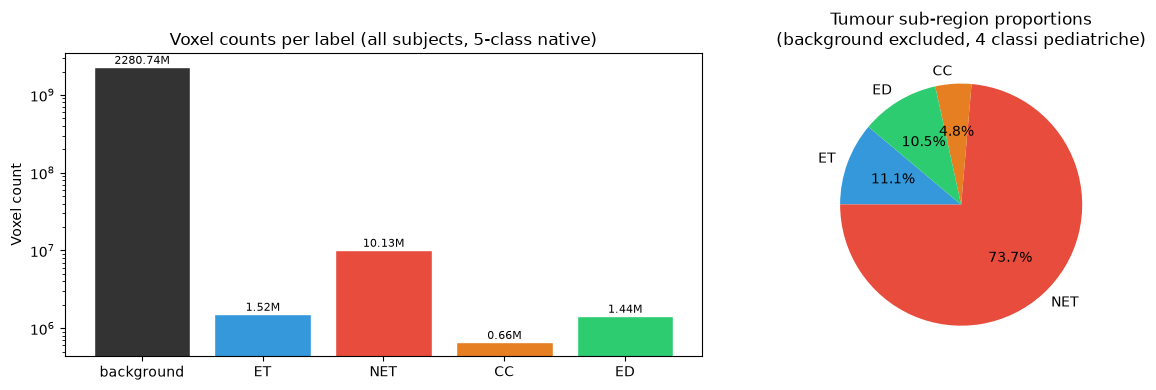

In [9]:
labels_plot = [CLASS_NAMES[k] for k in range(NUM_CLASSES)]
counts_plot = [label_counts[k] for k in range(NUM_CLASSES)]
colors = ['#333333', '#3498db', '#e74c3c', '#e67e22', '#2ecc71']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

bars = ax1.bar(labels_plot, counts_plot, color=colors, edgecolor='white')
ax1.set_title('Voxel counts per label (all subjects, 5-class native)')
ax1.set_ylabel('Voxel count')
ax1.set_yscale('log')
for bar, cnt in zip(bars, counts_plot):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.1,
             f'{cnt/1e6:.2f}M', ha='center', fontsize=8)

# Tumour-only pie (esclude il background) — 4 sub-regioni pediatriche
tumour_labels = [CLASS_NAMES[k] for k in range(1, NUM_CLASSES)]
tumour_counts = [label_counts[k] for k in range(1, NUM_CLASSES)]
ax2.pie(tumour_counts, labels=tumour_labels, autopct='%1.1f%%',
        colors=colors[1:], startangle=140)
ax2.set_title('Tumour sub-region proportions\n(background excluded, 4 classi pediatriche)')

plt.tight_layout()
plt.savefig('eda_3d_label_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

## 9. Summary

In [10]:
print('=== EDA Summary (3D pipeline) ===')
print(f'Training subjects : {len(subjects)}')
print(f'Volume shape      : {volumes["t1c"].shape}  (H x W x D)')
print(f'Voxel spacing (mm): {voxel_size}')
print(f'Modalities        : {MODALITIES}')
print(f'Labels (NATIVE, nessuna remap): {dict(enumerate(CLASS_NAMES))}')
print(f'Class imbalance   : ' + '  '.join(
    f'{CLASS_NAMES[k]}={100*label_counts[k]/total_voxels:.3f}%' for k in range(NUM_CLASSES)
))
print('\n=> Forte sbilancio di classe confermato, come nel 2D — la loss combinata Dice+Focal')
print('   (o Dice+Focal+GSL, ramo --loss=gsl) resta essenziale.')
print('=> A differenza del vecchio progetto 2D, NESSUNA remap label 4->3 e\' stata applicata:')
print('   le 5 classi pediatriche native (BG, ET, NET, CC, ED) sono preservate intatte,')
print('   pronte per il preprocessing (02_preprocessing_3d.ipynb) e il training 3D su Colab.')

=== EDA Summary (3D pipeline) ===
Training subjects : 257
Volume shape      : (240, 240, 155)  (H x W x D)
Voxel spacing (mm): (np.float32(1.0), np.float32(1.0), np.float32(1.0))
Modalities        : ['t1c', 't1n', 't2f', 't2w']
Labels (NATIVE, nessuna remap): {0: 'background', 1: 'ET', 2: 'NET', 3: 'CC', 4: 'ED'}
Class imbalance   : background=99.401%  ET=0.066%  NET=0.441%  CC=0.029%  ED=0.063%

=> Forte sbilancio di classe confermato, come nel 2D — la loss combinata Dice+Focal
   (o Dice+Focal+GSL, ramo --loss=gsl) resta essenziale.
=> A differenza del vecchio progetto 2D, NESSUNA remap label 4->3 e' stata applicata:
   le 5 classi pediatriche native (BG, ET, NET, CC, ED) sono preservate intatte,
   pronte per il preprocessing (02_preprocessing_3d.ipynb) e il training 3D su Colab.
